Some import needed for later and base function used later

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

import numpy as np
import matplotlib.pyplot as plt
import copy

import torch
from torch.utils.data import DataLoader, Subset
import torch.nn as nn

from src_base.AudioMnist import AudioMNIST 
from src_base.base_cnn import BaseCNN2D  
from src_base.Federated import Client, FedAvg 

# Collate function for AudioMNIST
def collate_fn(batch):
    data, labels = zip(*batch)
    data = torch.stack([d.squeeze() for d in data]).unsqueeze(1) 
    digit_labels = torch.tensor([l.squeeze()[0].item() for l in labels])
    return data, digit_labels


Load Data

In [7]:
batch_size = 16

# Load train dataset
train_dataset = AudioMNIST(
    root='./preprocessed_data',
    model_type='AlexNet',
    task='digit',
    split=0,
    mode='train'
)

# Load validation dataset
val_dataset = AudioMNIST(
    root='./preprocessed_data',
    model_type='AlexNet',
    task='digit',
    split=0,
    mode='validate'
)

# Create validation loader
valloader = DataLoader(val_dataset, batch_size=batch_size,
                      shuffle=False, num_workers=0, collate_fn=collate_fn)

# Load test dataset
test_dataset = AudioMNIST(
    root='./preprocessed_data',
    model_type='AlexNet',
    task='digit',
    split=0,
    mode='test'
)

testloader = DataLoader(test_dataset, batch_size=batch_size,
                       shuffle=False, num_workers=0, collate_fn=collate_fn)

# Define digit classes
digits = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')




In [5]:
# ==================== Initialize Model ====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

net = BaseCNN2D().to(device)

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

init_weights = copy.deepcopy(net.state_dict())




device: cuda:0
Trainable parameters: 365322


In [8]:
# ==================== Federated Learning Setup ====================
# Check with one client to see the difference

NUM_CLIENTS = 5          # number of clients
NUM_ROUNDS = 15          # number of rounds of federated learning
NUM_LOCAL_EPOCHS = 1     # number of local epochs
C = 1.0                  # fraction of clients to use per round
CLIENTS_PER_ROUND = int(NUM_CLIENTS * C)
LR = 0.001               # learning rate
DATA_SIZE = len(train_dataset)


criterion = nn.CrossEntropyLoss()

client_indices = torch.tensor_split(torch.randperm(DATA_SIZE), NUM_CLIENTS)


# Create clients
clients = [
    Client(net=BaseCNN2D( nb_class=10), 
           data=Subset(train_dataset, indices), 
           batch_size=batch_size, 
           criterion=criterion,
           collate_fn=collate_fn, 
           device=device, 
           LR=LR)
    for indices in client_indices
]

print(f"Samples per client: {len(client_indices[0]):d}")
print(f"Clients per round: {CLIENTS_PER_ROUND:d}")




Samples per client: 3600
Clients per round: 5


In [5]:
# ==================== Federated Training ====================
avg_test_loss = []
valid_accs = []

current_weights = copy.deepcopy(init_weights)

for round in range(NUM_ROUNDS):
    
    current_weights_cpu = {k: v.cpu() for k, v in current_weights.items()}
    
    # Random selection of clients
    client_ids = torch.randperm(NUM_CLIENTS)[:CLIENTS_PER_ROUND]
    local_weights = []
    temp_avg_loss = 0
    
    for id in client_ids:
        state_dict, loss = clients[id].train(NUM_LOCAL_EPOCHS, current_weights)
        local_weights.append(state_dict)
        temp_avg_loss += loss
    
    avg_test_loss.append(temp_avg_loss / CLIENTS_PER_ROUND)
    
    print(f"Round {round+1} done")
    print(f"training loss: {avg_test_loss[-1]:.3f}")
    
    # Federated averaging
    new_weights = FedAvg(local_weights)
    print("Federated Averaging done")
    
    current_weights = new_weights
    
    # Validation
    net.load_state_dict(current_weights)
    net.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for (inputs, labels) in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    valid_acc = correct / total
    valid_accs.append(valid_acc)
    
    if valid_acc > 0.95:  # Adjust target accuracy as needed
        print(f"validation accuracy reached 95% in {round+1:d} rounds")
        break
    
    print(f'Validation accuracy in round {round+1:d}: {100 * correct // total} %')




Round 1 done
training loss: 1.388
Federated Averaging done
Validation accuracy in round 1: 49 %
Round 2 done
training loss: 1.137
Federated Averaging done
Validation accuracy in round 2: 61 %
Round 3 done
training loss: 0.996
Federated Averaging done
Validation accuracy in round 3: 64 %
Round 4 done
training loss: 0.928
Federated Averaging done
Validation accuracy in round 4: 65 %
Round 5 done
training loss: 0.865
Federated Averaging done
Validation accuracy in round 5: 63 %
Round 6 done
training loss: 0.825
Federated Averaging done
Validation accuracy in round 6: 68 %
Round 7 done
training loss: 0.789
Federated Averaging done
Validation accuracy in round 7: 69 %
Round 8 done
training loss: 0.750
Federated Averaging done
Validation accuracy in round 8: 66 %
Round 9 done
training loss: 0.728
Federated Averaging done
Validation accuracy in round 9: 69 %
Round 10 done
training loss: 0.699
Federated Averaging done
Validation accuracy in round 10: 72 %
Round 11 done
training loss: 0.672
Fed

In [6]:
# ==================== Save Model ====================
torch.save(net.state_dict(), "models/fedavg_audiomnist_spectro.pth")




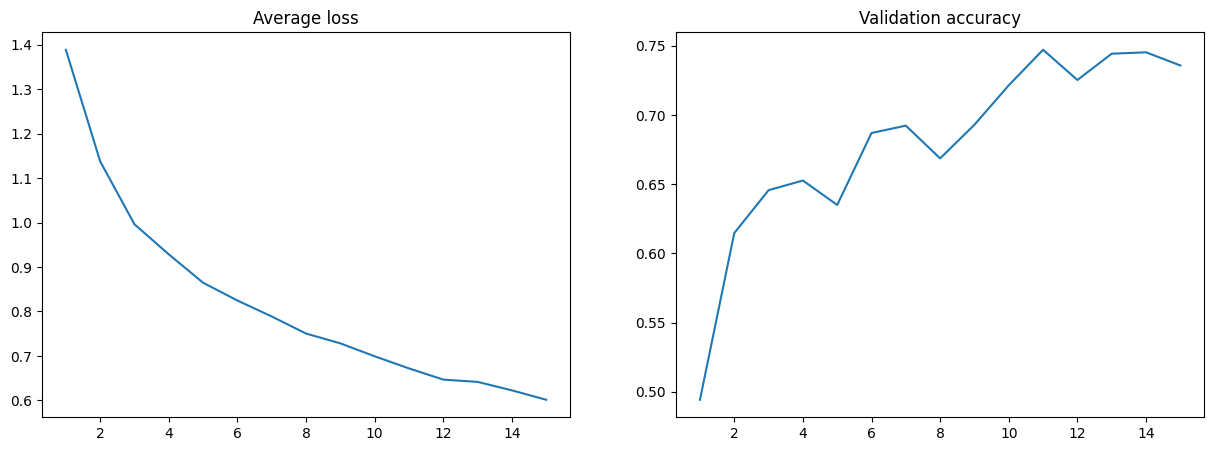

In [7]:
# ==================== Plot Results ====================
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(np.arange(1, len(avg_test_loss)+1), np.array(avg_test_loss))
axs[0].set_title("Average loss")

axs[1].plot(np.arange(1, len(valid_accs)+1), np.array(valid_accs))
axs[1].set_title("Validation accuracy")
plt.show()




In [9]:
# ==================== Test Evaluation ====================
net = BaseCNN2D( nb_class=10).to(device)
net.load_state_dict(torch.load("models/fedavg_audiomnist_spectro.pth", weights_only=True))
net.eval()

correct = 0
total = 0

with torch.no_grad():
    for (sounds, labels) in testloader:
        sounds, labels = sounds.to(device), labels.to(device)
        outputs = net(sounds)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on test set: {100 * correct // total} %')

# Per-class accuracy
correct_pred = {classname: 0 for classname in digits}
total_pred = {classname: 0 for classname in digits}

with torch.no_grad():
    for (sounds, labels) in testloader:
        sounds, labels = sounds.to(device), labels.to(device)
        outputs = net(sounds)
        _, predictions = torch.max(outputs, 1)
        
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[digits[label]] += 1
            total_pred[digits[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for digit {classname}: {accuracy:.1f} %')

Accuracy on test set: 77 %
Accuracy for digit 0: 70.8 %
Accuracy for digit 1: 80.0 %
Accuracy for digit 2: 86.5 %
Accuracy for digit 3: 64.8 %
Accuracy for digit 4: 57.2 %
Accuracy for digit 5: 85.0 %
Accuracy for digit 6: 87.8 %
Accuracy for digit 7: 77.3 %
Accuracy for digit 8: 90.7 %
Accuracy for digit 9: 78.5 %


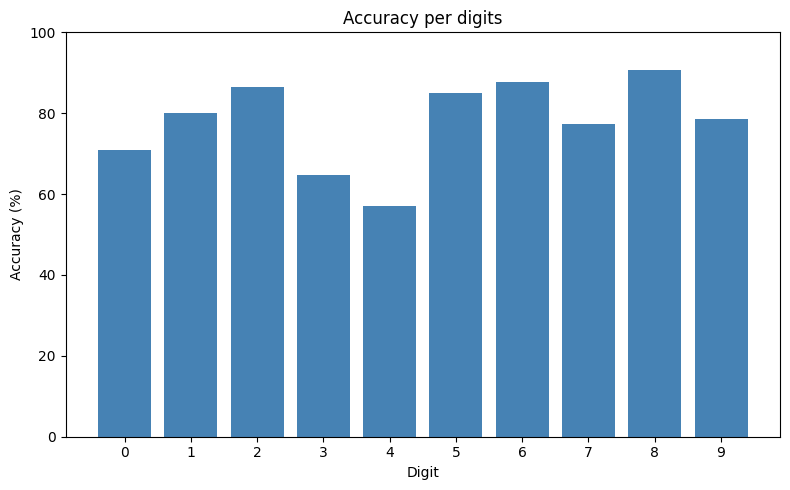

In [11]:
import matplotlib.pyplot as plt

digits = list(correct_pred.keys())
accuracies = [100 * float(correct_pred[c]) / total_pred[c] for c in digits]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(digits, accuracies, color='steelblue')

ax.set_xlabel('Digit')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy per digits')
ax.set_xticks(digits)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()